# Assign Polygon-Based Recharge Values to FEFLOW Model

In [1]:
import sys
import os
import platform

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import Point, Polygon

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D as Line
import matplotlib.tri as tri

golden_ratio = 1.618034
DHI_width = 15 # cm
inch_cm = 2.54 # inches / cm

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = [DHI_width / 1.5, (DHI_width / golden_ratio) / 1.5]   # inches
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# load IFM
ifmversion = '71'  # choose version here
arch = platform.architecture()[0][:2]
if 'FEFLOW' + ifmversion + '_ROOT' not in os.environ:
    raise EnvironmentError('FEFLOW' + ifmversion + '_ROOT Environment Variable not set!')
sys.path.append(os.environ['FEFLOW' + ifmversion + '_ROOT'] + '\\bin' + arch)
import ifm

In [2]:
filename_shape = "./testdata/full_coverage.shp"
filename_model = "./testdata/box_test.fem"
filename_table = ""

## Load the Recharge Zones (Shapefile)

Loads the Recharge zones from a shapefile. Overlapping polygons are allowed, the recharge will be applied cumulative. 

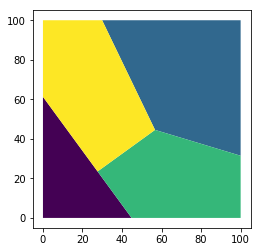

In [3]:
gdf_recharge = gpd.read_file(filename_shape)
gdf_recharge["recharge"] = [1.,2.,3.,4.]

gdf_recharge.plot(column='recharge')

## Load a FEFLOW Model as a GeoDataFrame

In [4]:
"""
load the nodes coordinates, the incidence matrix and the head field
"""

def read_feflowmesh(pdoc, global_cos=True, selection=None, elements=None, force_triangle=True):

    dd = doc.getNumberOfDimensions()
    
    if global_cos:
        X0 = doc.getOriginX()
        Y0 = doc.getOriginY()
    else:
        X0 = Y0 = 0

    x = []
    y = []

    if dd == 2:
        nn = doc.getNumberOfNodes()
        ee = doc.getNumberOfElements()
        stop = 1
    else:
        nn = doc.getNumberOfNodesPerSlice()
        ee = doc.getNumberOfElementsPerLayer()
        stop = 2

    for n in range(nn):
        x.append(doc.getX(n)+X0)
        y.append(doc.getY(n)+Y0)

    x = np.array(x)
    y = np.array(y)

    imat=[]

    for e in range(ee):  # PerLayer
        # skip inactive elements
        if not doc.getMatElementActive(e):
            continue
            
        # skip elements not in selection
        if selection is not None:
            selid = doc.findSelection(seltype, selection)
            if not doc.selectionItemIsSet(seltype, selid, e ):
                continue
                
        # skip elements not in element list:
        if elements is not None and e not in elements:
            continue
            
        NN = doc.getNumberOfElementNodes(e) / stop
        element_nodes = [doc.getNode(e, N) for N in range(NN)]
        if force_triangle:
            if NN == 3:
                imat.append(element_nodes)
            elif NN == 4:
                imat.append(element_nodes[:3])  # split quadrangle in 2 triangles
                imat.append(element_nodes[1:])
            else:
                raise ValueError(str(NN*2)+"-noded element not supported")
        else:
            imat.append(element_nodes)
    return (x,y,imat)

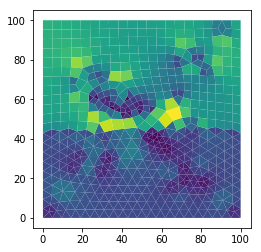

In [5]:
# load the model
ifm.forceLicense("Viewer")
doc = ifm.loadDocument(filename_model)

# create a GeoDataFrame from the mesh
x, y, imat = read_feflowmesh(doc, force_triangle=False)
gdf_elements = gpd.GeoDataFrame([Polygon([(x[n], y[n]) for n in element]) for element in imat])
gdf_elements.columns = ["element_shape"]
gdf_elements.set_geometry("element_shape", inplace=True)
gdf_elements.index.name = "ELEMENT"
gdf_elements["ELEMENT"] = gdf_elements.index.values
gdf_elements["AREA"] = gdf_elements.geometry.area

# plot mesh
gdf_elements.plot(column="AREA")

## Create the Weights matrix and calculate elemental recharge

A translation matrix $A$ is created that allows the transformation of polygonal recharge values $F_{polygonal}$ to elemental recharge values $F_{elemental}$:

$$A = a_{i,j} = \frac{A^{overlap}_{i,j}}{A^{total}_{i}}$$ 

with $A^{total}_{i}$ as the total area of element i and $A^{overlap}_{i,j}$ the overlapping area of element $i$ with polygon $j$. 

The elemental values can then be determined without loss of mass conservation by

$$F_{elemental} = A \cdot F_{polygonal}$$

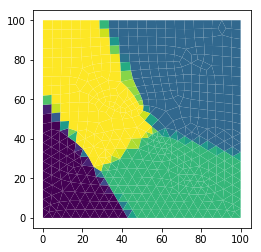

In [6]:
# intersect the elements with the recharge polygons
res_intersect = gpd.overlay(gdf_recharge, gdf_elements, how="intersection")
res_intersect["AREA_PART"] = res_intersect.geometry.area
res_intersect["weight"] = res_intersect.AREA_PART / res_intersect.AREA

# create a matrix with weights
df_matrix = pd.DataFrame(index=sorted(res_intersect.ELEMENT.unique()), 
                         columns=sorted(res_intersect.ID.unique()), 
                         dtype=np.float64)
df_matrix[:] = 0.
for element, row in res_intersect.iterrows():
    df_matrix.loc[row.ELEMENT, row.ID] += row.weight

# calculate the elemental recharge
gdf_elements["RECHARGE"] = np.dot(df_matrix, gdf_recharge.recharge.T)
gdf_elements.plot(column="RECHARGE")